In [1]:

import re
import ssl
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer, word_tokenize

try:
    _create_unverified_https_context = ssl._create_unverified_context
    ssl._create_default_https_context = _create_unverified_https_context
except AttributeError:
    pass
#ako su potrebne instalacije 
#nltk.download("stopwords")
#nltk.download("wordnet")


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import TruncatedSVD


from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import  ComplementNB
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)


import joblib

In [2]:
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/matrices", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

In [3]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

In [4]:
data=pd.read_csv('../../Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
data_small, _ = train_test_split(
    data,
    train_size=50000,
    stratify=data["Score"],
    random_state=42
)
data_small["Score"].value_counts()

Score
5    31940
4     7094
1     4597
3     3751
2     2618
Name: count, dtype: int64

In [6]:
data_small["TextFull"] = data_small["Summary"].fillna("") + " " + data_small["Text"].fillna("")
data_small["HelpfulnessRatio"] = data_small["HelpfulnessNumerator"] / (data_small["HelpfulnessDenominator"] + 1e-9)


In [7]:
data_small["cleaned_full"] = data_small["TextFull"].apply(clean_text)
num_cols = ["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]

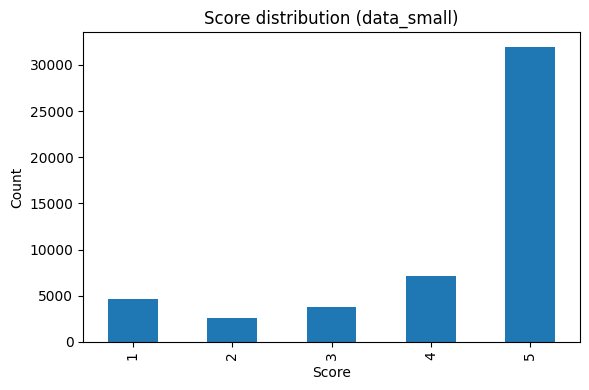

In [8]:
plt.figure(figsize=(6,4))
data_small["Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Score distribution (data_small)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

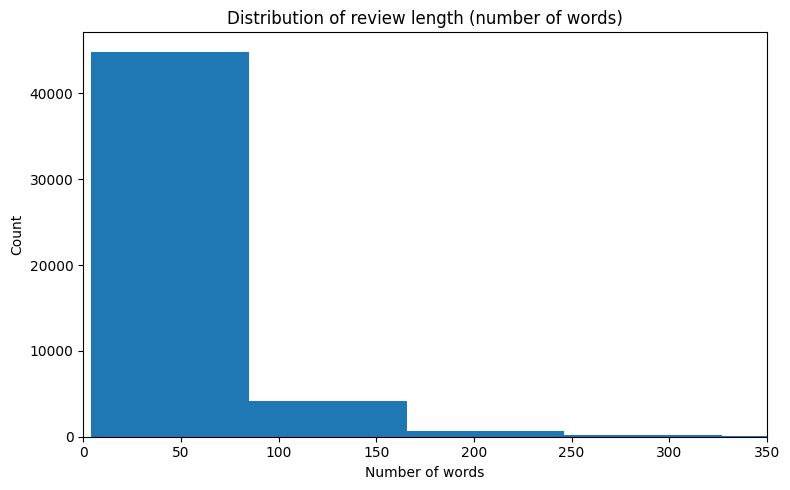

In [9]:
data_small["text_length"] = data_small["cleaned_full"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))

plt.hist(data_small["text_length"], bins=25)
plt.xlim(0, 350)   # ograničimo raspon

plt.title("Distribution of review length (number of words)")
plt.xlabel("Number of words")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [10]:
text_col = "cleaned_full"
num_cols = ["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]

In [11]:
data_small.to_csv("processed_reviews.csv", index=False)
print("Processed dataset saved.")

Processed dataset saved.


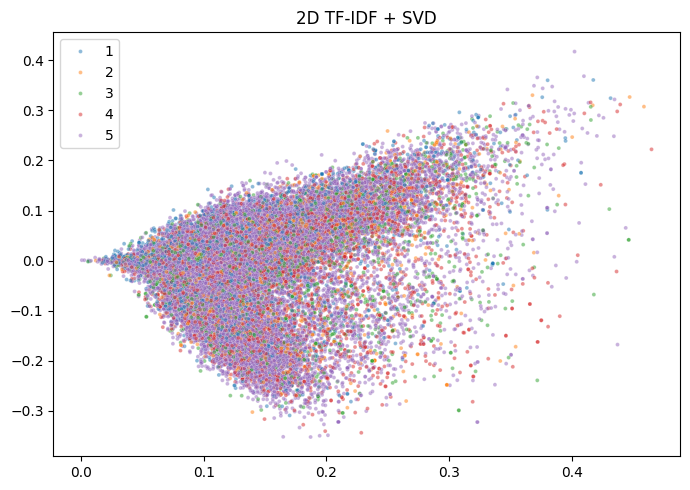

In [12]:
tfidf_vis = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2)
X_tfidf = tfidf_vis.fit_transform(data_small["cleaned_full"].fillna(""))
y_vis = data_small["Score"].astype(int).values

svd2 = TruncatedSVD(n_components=2, random_state=42)
X2 = svd2.fit_transform(X_tfidf)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X2[:,0], y=X2[:,1], hue=y_vis, palette="tab10", s=8, alpha=0.5)
plt.savefig("results/figures/2D.png", dpi=300, bbox_inches="tight")

plt.title("2D TF-IDF + SVD")
plt.tight_layout()
plt.show()

Explained variance ratio (sum): 0.016912992924787235


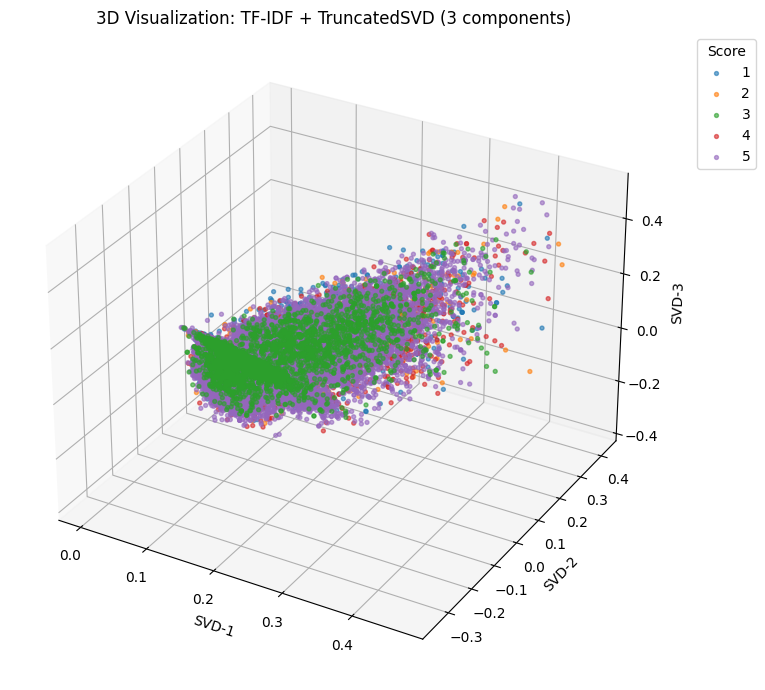

In [13]:
texts = data_small["cleaned_full"].fillna("")
y = data_small["Score"].astype(int).values

# TF-IDF (isti princip kao u modelima)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_3d = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000,
    min_df=2
)

X_tfidf = tfidf_3d.fit_transform(texts)

# SVD na 3 komponente
svd3 = TruncatedSVD(n_components=3, random_state=42)
X_3d = svd3.fit_transform(X_tfidf)

print("Explained variance ratio (sum):", svd3.explained_variance_ratio_.sum())

# 3D scatter
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

classes = np.sort(np.unique(y))
for c in classes:
    idx = (y == c)
    ax.scatter(
        X_3d[idx, 0],
        X_3d[idx, 1],
        X_3d[idx, 2],
        s=8,
        alpha=0.6,
        label=str(c)
    )

ax.set_title("3D Visualization: TF-IDF + TruncatedSVD (3 components)")
plt.savefig("results/figures/3D.png", dpi=300, bbox_inches="tight")

ax.set_xlabel("SVD-1")
ax.set_ylabel("SVD-2")
ax.set_zlabel("SVD-3")
ax.legend(title="Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [14]:
X = data_small[["cleaned_full", "HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]]
y = data_small["Score"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
train_df = X_train.copy()
train_df["Score"] = y_train.values

min_count = train_df["Score"].value_counts().min()

train_bal = (
    train_df.groupby("Score", group_keys=False)
    .apply(lambda g: g.sample(min_count, random_state=42))
)

X_train_bal = train_bal.drop(columns=["Score"])
y_train_bal = train_bal["Score"]

In [16]:

def make_preprocessor(max_features=20000):
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1,2), min_df=2)
    return ColumnTransformer(
        transformers=[
            ("text", Pipeline([("tfidf", tfidf)]), text_col),
            ("num", MaxAbsScaler(), num_cols)
        ],
        remainder="drop"
    )

In [17]:
models = {
    "LinearSVC": LinearSVC(dual="auto", max_iter=5000),
    "SGD hinge": SGDClassifier(loss="hinge", random_state=42),
    "LogReg": LogisticRegression(max_iter=500, n_jobs=-1),
    "Random forest": RandomForestClassifier(n_estimators=300,max_depth=30,max_features="sqrt",min_samples_split=5,n_jobs=-1,
    random_state=42),
    "ComplementNB": ComplementNB(),
}

def run_block(Xtr, Xte, ytr, yte, dataset_label, max_features):
    pre = make_preprocessor(max_features=max_features)
    rows = []
    
    total_models = len(models)
    
    print(f"\n=== Dataset: {dataset_label} | TFIDF: {max_features} ===")
    
    for i, (name, model) in enumerate(models.items(), 1):
        print(f"[{i}/{total_models}] Trening modela: {name} ...", end=" ")
        
        pipe = Pipeline([("pre", pre), ("clf", clone(model))])
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)
        
        acc = accuracy_score(yte, pred)
        f1m = f1_score(yte, pred, average="macro")
        f1w = f1_score(yte, pred, average="weighted")
        
        print(f"done | Acc={acc:.4f} | F1_macro={f1m:.4f}| F1_weighted={f1w:.4f}")
        
        rows.append({
            "Dataset": dataset_label,
            "TFIDF": f"{max_features}",
            "Model": name,
            "Accuracy": acc,
            "F1_macro": f1m,
            "F1_weighted": f1w
        })
        
    return rows

In [18]:
rows = []
for k in [10000, 20000]:
    rows += run_block(X_train, X_test, y_train, y_test, "RAW", k)
    rows += run_block(X_train_bal, X_test, y_train_bal, y_test, "BAL", k)

results_df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df


=== Dataset: RAW | TFIDF: 10000 ===
[1/5] Trening modela: LinearSVC ... done | Acc=0.7337 | F1_macro=0.5170| F1_weighted=0.7088
[2/5] Trening modela: SGD hinge ... done | Acc=0.7185 | F1_macro=0.4106| F1_weighted=0.6460
[3/5] Trening modela: LogReg ... done | Acc=0.7350 | F1_macro=0.4830| F1_weighted=0.6942
[4/5] Trening modela: Random forest ... done | Acc=0.6519 | F1_macro=0.2100| F1_weighted=0.5263
[5/5] Trening modela: ComplementNB ... done | Acc=0.6909 | F1_macro=0.4598| F1_weighted=0.6818

=== Dataset: BAL | TFIDF: 10000 ===
[1/5] Trening modela: LinearSVC ... done | Acc=0.5764 | F1_macro=0.4550| F1_weighted=0.6128
[2/5] Trening modela: SGD hinge ... done | Acc=0.6212 | F1_macro=0.4706| F1_weighted=0.6452
[3/5] Trening modela: LogReg ... done | Acc=0.6016 | F1_macro=0.4726| F1_weighted=0.6346
[4/5] Trening modela: Random forest ... done | Acc=0.6387 | F1_macro=0.4818| F1_weighted=0.6565
[5/5] Trening modela: ComplementNB ... done | Acc=0.6243 | F1_macro=0.4680| F1_weighted=0.643

,Dataset,TFIDF,Model,Accuracy,F1_macro,F1_weighted
10,RAW,20000,LinearSVC,0.7360,0.521235,0.712965
0,RAW,10000,LinearSVC,0.7337,0.517008,0.708817
18,BAL,20000,Random forest,0.6440,0.488679,0.661454
2,RAW,10000,LogReg,0.7350,0.483002,0.694199
17,BAL,20000,LogReg,0.6107,0.482879,0.642266
12,RAW,20000,LogReg,0.7346,0.481962,0.692625
8,BAL,10000,Random forest,0.6387,0.481762,0.656548
16,BAL,20000,SGD hinge,0.6254,0.479205,0.648707
14,RAW,20000,ComplementNB,0.7104,0.476022,0.694217
7,BAL,10000,LogReg,0.6016,0.472636,0.634592


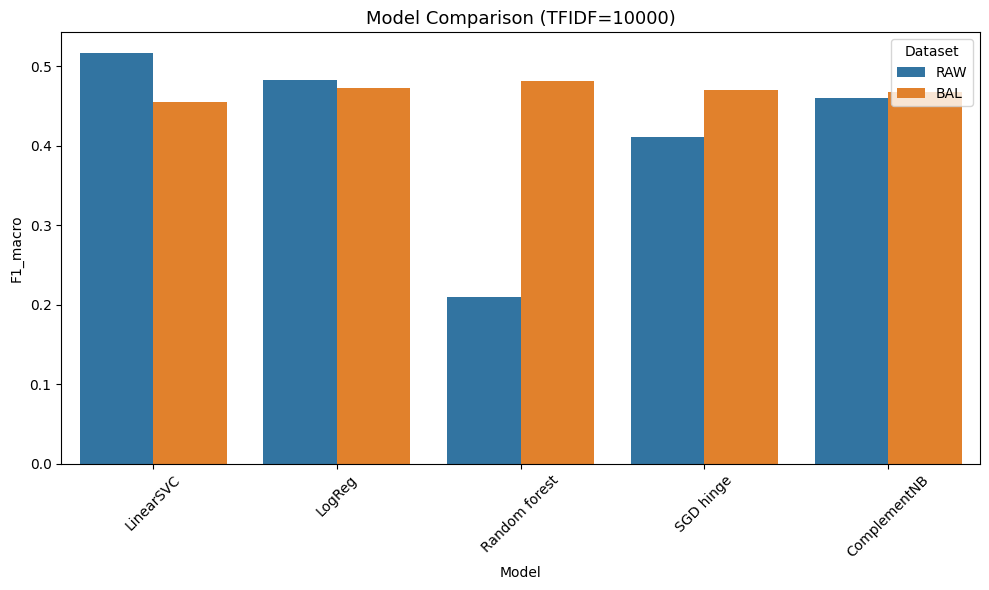

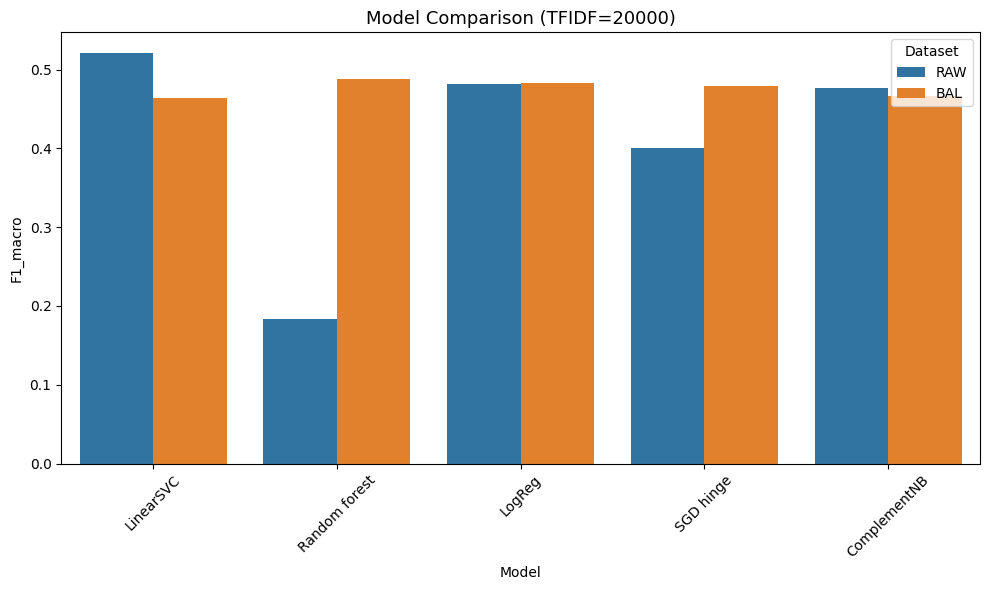

In [21]:
for tfidf_name in ["10000", "20000"]:
    plt.figure(figsize=(10,6))
    
    sub = results_df[results_df["TFIDF"] == tfidf_name]
    
    sns.barplot(
        data=sub,
        x="Model",
        y="F1_macro",
        hue="Dataset",
    )
    
    plt.xticks(rotation=45)
    plt.title(f"Model Comparison (TFIDF={tfidf_name})", fontsize=13)
    filename = f"results/fifigure/bar_polt_all{sub}.png"

    filename = f"results/figures/bar_plot_all_{tfidf_name}.png"

    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()

In [22]:
def show_cm_raw_vs_bal_for_model(
    model_name,
    max_features,
    X_train, y_train,
    X_train_bal, y_train_bal,
    X_test, y_test,
    title_prefix="SCORE",
    normalize="true"

):
    
    pre = make_preprocessor(max_features=max_features)

    print("="*90)
    print(f"{title_prefix} | Model: {model_name} | TFIDF: {max_features}")
    print("="*90)

    pipe_raw = Pipeline([("pre", pre), ("clf", clone(models[model_name]))])
    pipe_raw.fit(X_train, y_train)

    pred_raw_tr = pipe_raw.predict(X_train)
    pred_raw_te = pipe_raw.predict(X_test)

    cm_raw_tr = confusion_matrix(y_train, pred_raw_tr, normalize=normalize)
    cm_raw_te = confusion_matrix(y_test,  pred_raw_te, normalize=normalize)

    # --- BAL ---
    pipe_bal = Pipeline([("pre", pre), ("clf", clone(models[model_name]))])
    pipe_bal.fit(X_train_bal, y_train_bal)

    pred_bal_tr = pipe_bal.predict(X_train_bal)
    pred_bal_te = pipe_bal.predict(X_test)

    cm_bal_tr = confusion_matrix(y_train_bal, pred_bal_tr,  normalize=normalize)
    cm_bal_te = confusion_matrix(y_test,      pred_bal_te,  normalize=normalize)

    # --- Plot 2x2 ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ConfusionMatrixDisplay(cm_raw_tr).plot(ax=axes[0,0], cmap="Blues", colorbar=False)
    axes[0,0].set_title("RAW | TRAIN")
    axes[0,0].grid(False)

    ConfusionMatrixDisplay(cm_raw_te).plot(ax=axes[0,1], cmap="Blues", colorbar=False)
    axes[0,1].set_title("RAW | TEST")
    axes[0,1].grid(False)

    ConfusionMatrixDisplay(cm_bal_tr).plot(ax=axes[1,0], cmap="Blues", colorbar=False)
    axes[1,0].set_title("BAL | TRAIN")
    axes[1,0].grid(False)

    ConfusionMatrixDisplay(cm_bal_te).plot(ax=axes[1,1], cmap="Blues", colorbar=False)
    axes[1,1].set_title("BAL | TEST")
    axes[1,1].grid(False)

    plt.suptitle(f"{title_prefix}: {model_name} | TFIDF {max_features}", fontsize=14)
    filename = f"results/matrices/cm_all{title_prefix.lower()}_{model_name.lower()}_{max_features}.png"

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

    # --- Reports ---
    print("\n--- RAW | TRAIN report ---")
    print(classification_report(y_train, pred_raw_tr))

    print("\n--- RAW | TEST report ---")
    print(classification_report(y_test, pred_raw_te))

    print("\n--- BAL | TRAIN report ---")
    print(classification_report(y_train_bal, pred_bal_tr))

    print("\n--- BAL | TEST report ---")
    print(classification_report(y_test, pred_bal_te))

SCORE | Model: LinearSVC | TFIDF: 20000


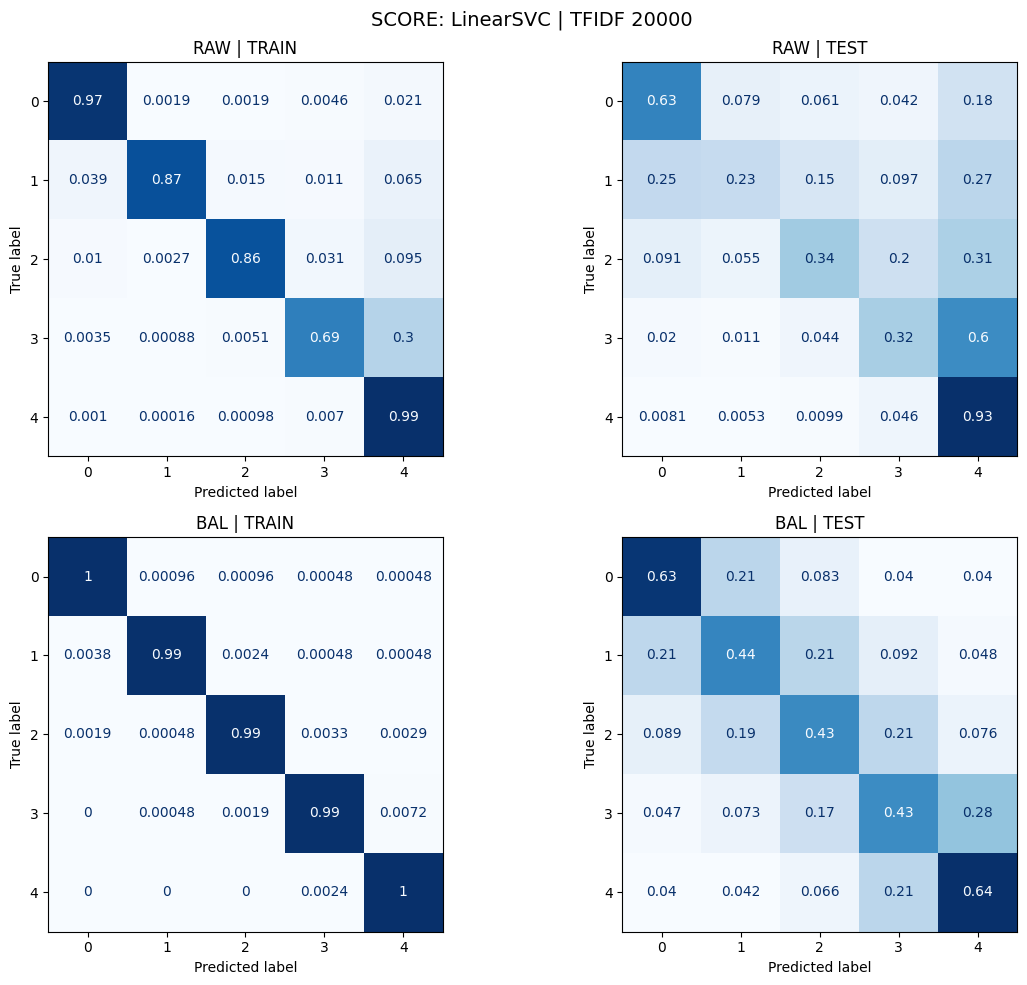


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.96      0.97      0.96      3678
           2       0.99      0.87      0.92      2094
           3       0.97      0.86      0.91      3001
           4       0.93      0.69      0.79      5675
           5       0.92      0.99      0.95     25552

    accuracy                           0.93     40000
   macro avg       0.95      0.88      0.91     40000
weighted avg       0.93      0.93      0.93     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.68      0.63      0.65       919
           2       0.43      0.23      0.30       524
           3       0.49      0.34      0.40       750
           4       0.46      0.32      0.38      1419
           5       0.81      0.93      0.87      6388

    accuracy                           0.74     10000
   macro avg       0.57      0.49      0.52     10000
weighted avg       0.7

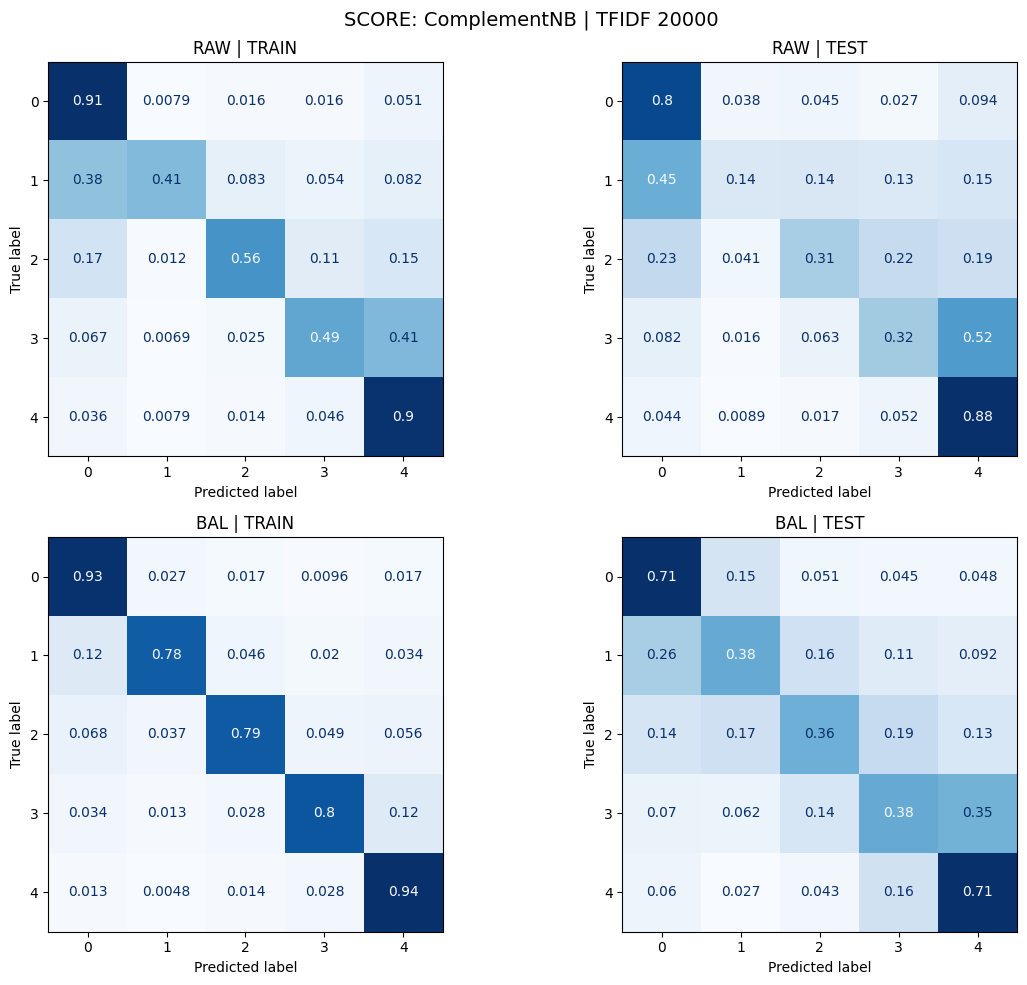


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.56      0.91      0.69      3678
           2       0.74      0.41      0.52      2094
           3       0.69      0.56      0.62      3001
           4       0.62      0.49      0.55      5675
           5       0.88      0.90      0.89     25552

    accuracy                           0.79     40000
   macro avg       0.70      0.65      0.65     40000
weighted avg       0.79      0.79      0.78     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.48      0.80      0.60       919
           2       0.33      0.14      0.19       524
           3       0.43      0.31      0.36       750
           4       0.44      0.32      0.37      1419
           5       0.84      0.88      0.86      6388

    accuracy                           0.71     10000
   macro avg       0.50      0.49      0.48     10000
weighted avg       0.6

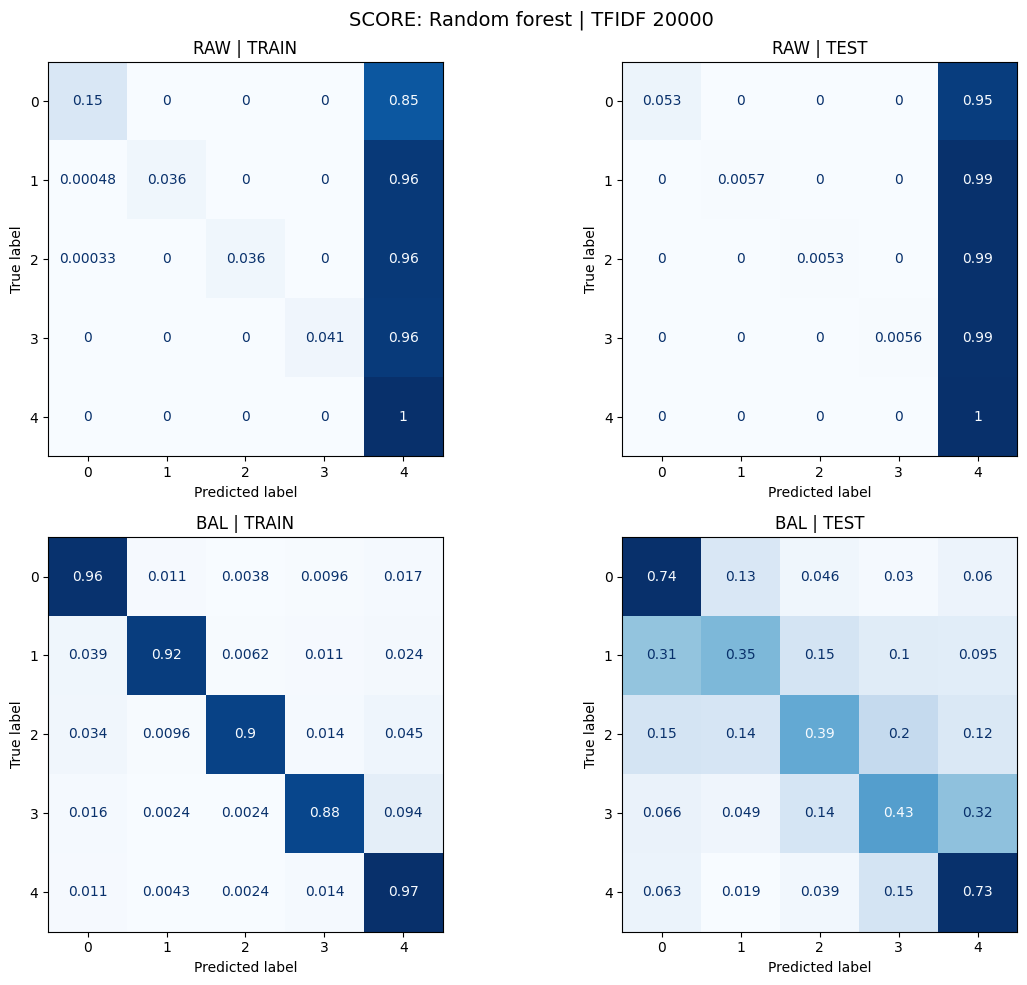


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       1.00      0.15      0.26      3678
           2       1.00      0.04      0.07      2094
           3       1.00      0.04      0.07      3001
           4       1.00      0.04      0.08      5675
           5       0.65      1.00      0.79     25552

    accuracy                           0.66     40000
   macro avg       0.93      0.25      0.25     40000
weighted avg       0.78      0.66      0.55     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       1.00      0.05      0.10       919
           2       1.00      0.01      0.01       524
           3       1.00      0.01      0.01       750
           4       1.00      0.01      0.01      1419
           5       0.64      1.00      0.78      6388

    accuracy                           0.65     10000
   macro avg       0.93      0.21      0.18     10000
weighted avg       0.7

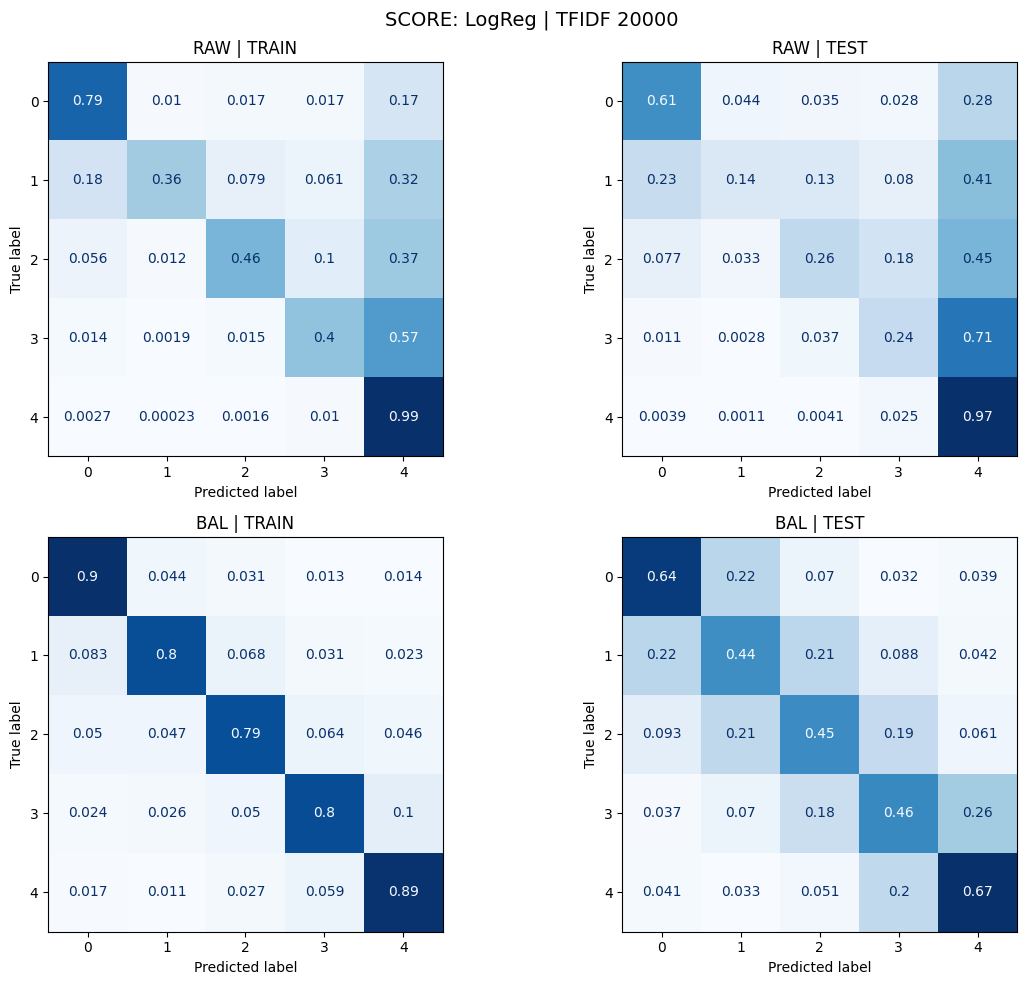


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.81      0.79      0.80      3678
           2       0.89      0.36      0.51      2094
           3       0.80      0.46      0.58      3001
           4       0.75      0.40      0.52      5675
           5       0.82      0.99      0.89     25552

    accuracy                           0.81     40000
   macro avg       0.81      0.60      0.66     40000
weighted avg       0.81      0.81      0.79     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.72      0.61      0.66       919
           2       0.50      0.14      0.22       524
           3       0.52      0.26      0.34       750
           4       0.49      0.24      0.32      1419
           5       0.77      0.97      0.86      6388

    accuracy                           0.73     10000
   macro avg       0.60      0.44      0.48     10000
weighted avg       0.6

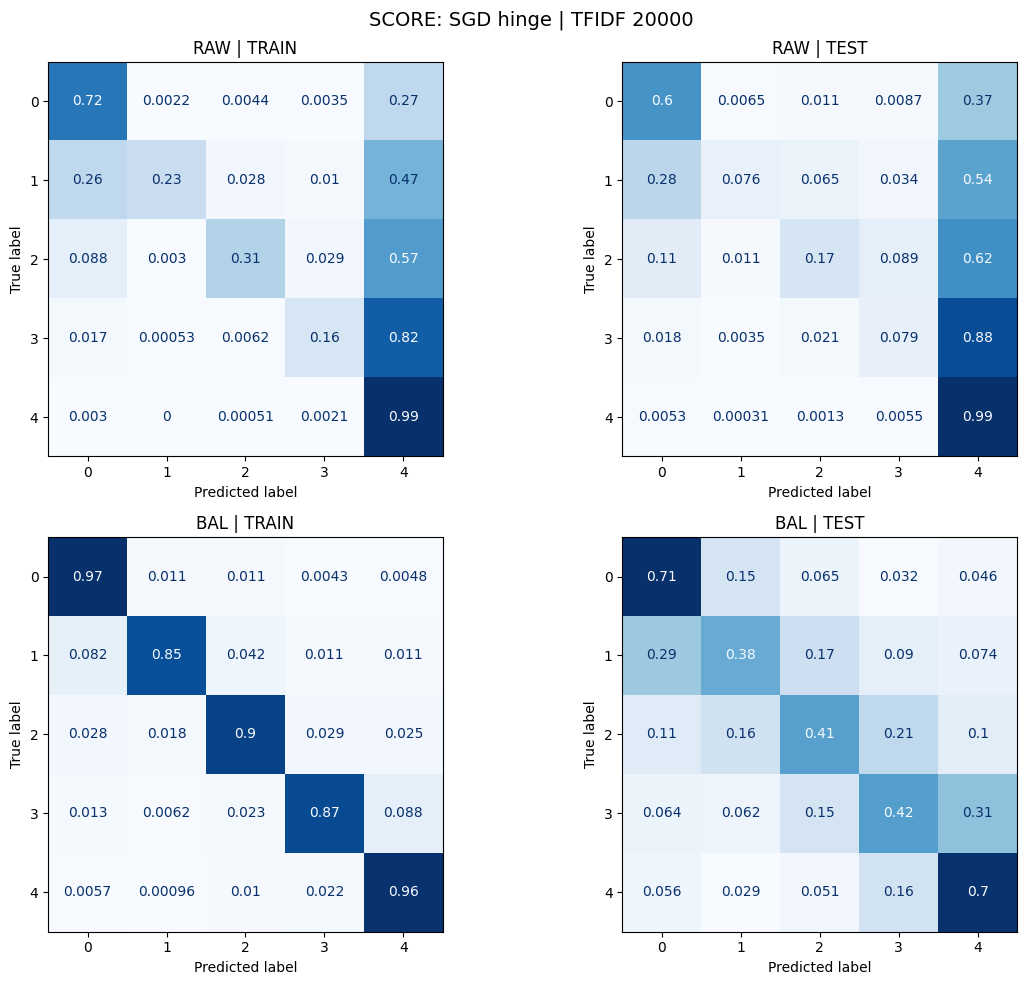


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.73      0.72      0.73      3678
           2       0.96      0.23      0.37      2094
           3       0.88      0.31      0.46      3001
           4       0.84      0.16      0.27      5675
           5       0.75      0.99      0.86     25552

    accuracy                           0.76     40000
   macro avg       0.83      0.48      0.53     40000
weighted avg       0.78      0.76      0.71     40000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.66      0.60      0.63       919
           2       0.66      0.08      0.14       524
           3       0.60      0.17      0.26       750
           4       0.47      0.08      0.14      1419
           5       0.73      0.99      0.84      6388

    accuracy                           0.71     10000
   macro avg       0.62      0.38      0.40     10000
weighted avg       0.6

In [23]:
chosen_models = ["LinearSVC", "ComplementNB", "Random forest","LogReg","SGD hinge"]

for m in chosen_models:
    show_cm_raw_vs_bal_for_model(
        model_name=m,
        max_features=20000,
        X_train=X_train, y_train=y_train,
        X_train_bal=X_train_bal, y_train_bal=y_train_bal,
        X_test=X_test, y_test=y_test,
        title_prefix="SCORE",
    )

In [24]:
best = results_df.sort_values("F1_macro", ascending=False).iloc[0]

best_dataset = best["Dataset"]         
best_k = int(best["TFIDF"])             
best_model_name = best["Model"]         

print("BEST CONFIG:", best.to_dict())

pre = make_preprocessor(max_features=best_k)
pipe = Pipeline([
    ("pre", pre),
    ("clf", clone(models[best_model_name]))
])

if best_dataset == "RAW":
    pipe.fit(X_train, y_train)
else:
    pipe.fit(X_train_bal, y_train_bal)

ct = pipe.named_steps["pre"]
clf = pipe.named_steps["clf"]

tfidf = ct.named_transformers_["text"].named_steps["tfidf"]
text_names = tfidf.get_feature_names_out()

num_names = np.array(["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"])
feature_names = np.concatenate([text_names, num_names])

top_n = 10
classes = clf.classes_

table = {}
for i, cls in enumerate(classes):
    coef = clf.coef_[i] 
    top_idx = np.argsort(coef)[-top_n:][::-1]
    table[f"Score_{cls}"] = feature_names[top_idx]

final_df = pd.DataFrame(table)
final_df

BEST CONFIG: {'Dataset': 'RAW', 'TFIDF': '20000', 'Model': 'LinearSVC', 'Accuracy': 0.736, 'F1_macro': 0.521234990313818, 'F1_weighted': 0.7129645978656416}


,Score_1,Score_2,Score_3,Score_4,Score_5
0,HelpfulnessDenominator,two star,three star,four star,HelpfulnessNumerator
1,worst,nearly good,okay,reason give,best
2,terrible,lacked,ok,star,great
3,awful,way sweet,alright,complaint,amazing
4,one star,unfortunately,however,gave star,love
5,disgusting,disappointed,usually love,pretty good,awesome
6,gross,coffee weak,inconsistent,say best,excellent
7,horrible,completely different,nothing special,treat never,five star
8,yuck,expires,product expensive,criticism,perfect
9,rip,sadly,good great,flavor strong,delicious


In [25]:
joblib.dump(pipe, "best_model.joblib")

print("Model uspešno sačuvan kao best_model.joblib")

Model uspešno sačuvan kao best_model.joblib


In [26]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pre = make_preprocessor(max_features=20000)

pipe = Pipeline([
    ("pre", pre),
    ("clf", LinearSVC(dual="auto", max_iter=5000))
])

scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("CV F1-macro:", scores.mean(), "+/-", scores.std())

CV F1-macro: 0.5150157621823426 +/- 0.006005572274586482


In [27]:

pipe = Pipeline([
    ("pre", make_preprocessor(max_features=20000)),
    ("clf", LinearSVC(dual="auto", max_iter=5000))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "pre__text__tfidf__ngram_range": [(1,2), (1,3)],
    "pre__text__tfidf__min_df": [2, 5],
}

gs = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV F1_macro:", gs.best_score_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'clf__C': 1, 'pre__text__tfidf__min_df': 2, 'pre__text__tfidf__ngram_range': (1, 2)}
Best CV F1_macro: 0.5078658987471295
